In [ ]:
#!pip install requests beautifulsoup4
import requests
from bs4 import BeautifulSoup


   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ----- ---------------------------------- 1/8 [typing-extensions]
   ----- ---------------------------------- 1/8 [typing-extensions]
   ---------- ----------------------------- 2/8 [soupsieve]
   ---------- ----------------------------- 2/8 [soupsieve]
   --------------- ------------------------ 3/8 [idna]
   --------------- ------------------------ 3/8 [idna]
   -------------------- ------------------- 4/8 [charset_normalizer]
   -------------------- ------------------

In [4]:
# URL da vítima
url = "https://motor1.uol.com.br/news/791853/carros-mais-vendidos-marco-onix/"

# Cabeçalho para simular um navegador
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

In [5]:
response = requests.get(url, headers=headers)
response

<Response [200]>

In [6]:
response.text

'<!DOCTYPE html><html class="document" prefix="og: http://ogp.me/ns#" lang="pt-br">\n<head>\n    <meta charset="utf-8">\n    <title>BYD Dolphin Mini com recorde: os carros mais vendidos de março</title>\n\n            <style>\n            #trending-791853 {display: none;}\n            [data-most-recent-id="791853"] {display: none;}\n            [data-trending-id="791853"] {display: none;}\n            .latest__articles-list [data-most-recent-id="791853"] {display: none;}\n            .latest__articles-list > [data-most-recent-id="791853"] ~ li:last-child {display: flex;}\n        </style>\n    \n    <link rel="icon" type="image/png" sizes="32x32" href="https://cdn.motor1.com/images/static/motor1/favicon-32.png">\n    <link rel="icon" type="image/png" sizes="96x96" href="https://cdn.motor1.com/images/static/motor1/favicon-96.png">\n    <link rel="icon" type="image/png" sizes="128x128" href="https://cdn.motor1.com/images/static/motor1/favicon-128.png">\n    <link rel="icon" type="image/p

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

In [8]:
soup

<!DOCTYPE html>
<html class="document" lang="pt-br" prefix="og: http://ogp.me/ns#">
<head>
<meta charset="utf-8"/>
<title>BYD Dolphin Mini com recorde: os carros mais vendidos de março</title>
<style>
            #trending-791853 {display: none;}
            [data-most-recent-id="791853"] {display: none;}
            [data-trending-id="791853"] {display: none;}
            .latest__articles-list [data-most-recent-id="791853"] {display: none;}
            .latest__articles-list > [data-most-recent-id="791853"] ~ li:last-child {display: flex;}
        </style>
<link href="https://cdn.motor1.com/images/static/motor1/favicon-32.png" rel="icon" sizes="32x32" type="image/png"/>
<link href="https://cdn.motor1.com/images/static/motor1/favicon-96.png" rel="icon" sizes="96x96" type="image/png"/>
<link href="https://cdn.motor1.com/images/static/motor1/favicon-128.png" rel="icon" sizes="128x128" type="image/png"/>
<link href="https://cdn.motor1.com/images/static/motor1/favicon-195.png" rel="icon" 

In [9]:
# Exibe o html como texto
print(soup.get_text())




BYD Dolphin Mini com recorde: os carros mais vendidos de março

































































 
















 
   

















BYD Dolphin Mini com recorde: os carros mais vendidos de março



















                                            Notícias                                    






Mercado
Análise
Oficial
Indústria
Segredos
Lançamentos


                                                                                                    Todas as notícias                                                                










                                            Testes                                    






Avaliações
Teste Especial
Teste dos 360 km
Comparativos
Primeira Impressão
Por que Comprar?


                                                                Todas as avaliações                                                                










                                            Destaques    

In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://motor1.uol.com.br/news/791853/carros-mais-vendidos-marco-onix/"

def extrair_tabela_vendas(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"Acessando: {url}")
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Encontrar a tabela no conteúdo do artigo
    table = soup.find('table') # <--- Aqui procuramos a tag <table>
    if not table:
        print("Tabela não encontrada.")
        return None
    
    rows = table.find_all('tr') # <--- Dentro da tabela, procuramos todas as tags <tr> (linhas)
    data = []
    
    for row in rows:
        cols = row.find_all('td') # <--- Para cada linha, procuramos todas as tags <td> (células)
        cols = [ele.text.strip() for ele in cols] # <--- Extraímos o texto de cada célula e removemos espaços extras
        if cols:
            data.append(cols) # <--- Adicionamos a lista de células (uma linha) à nossa lista de dados
    
    # A primeira linha costuma ser o cabeçalho
    if data:
        # Criamos um DataFrame do Pandas. A primeira linha de 'data' são os cabeçalhos.
        df = pd.DataFrame(data[1:], columns=data[0]) 
        return df
    return None

if __name__ == "__main__":
    url = "https://motor1.uol.com.br/news/791853/carros-mais-vendidos-marco-onix/"
    df_vendas = extrair_tabela_vendas(url )
    
    if df_vendas is not None:
        # Limpeza simples: remover caracteres não numéricos de colunas que deveriam ser números
        # A coluna de vendas (ex: 'MAR.2026') tem pontos como separador de milhar. Removemos para converter para número.
        col_vendas = df_vendas.columns[2] # Pega o nome da terceira coluna, que é a de vendas
        df_vendas[col_vendas] = df_vendas[col_vendas].str.replace('.', '', regex=False).astype(int)
        
        df_vendas.to_csv('vendas_marco.csv', index=False)
        print("Dados extraídos com sucesso!")
        print(df_vendas.head())

Acessando: https://motor1.uol.com.br/news/791853/carros-mais-vendidos-marco-onix/
Dados extraídos com sucesso!
  POS.          MODELO  MAR.2026
0   1º     FIAT STRADA     16706
1   2º         VW POLO     11051
2   3º  CHEVROLET ONIX     10182
3   4º       FIAT ARGO      8281
4   5º         VW TERA      7977


C:\Users\muvil\AppData\Local\Temp\ipykernel_27100\1156441801.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x=col_vendas, y='MODELO', palette='Blues_d') # Cria o gráfico de barras
C:\Users\muvil\AppData\Local\Temp\ipykernel_27100\1156441801.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_marca.values, y=vendas_por_marca.index, palette='Reds_d')


Análise de vendas concluída!


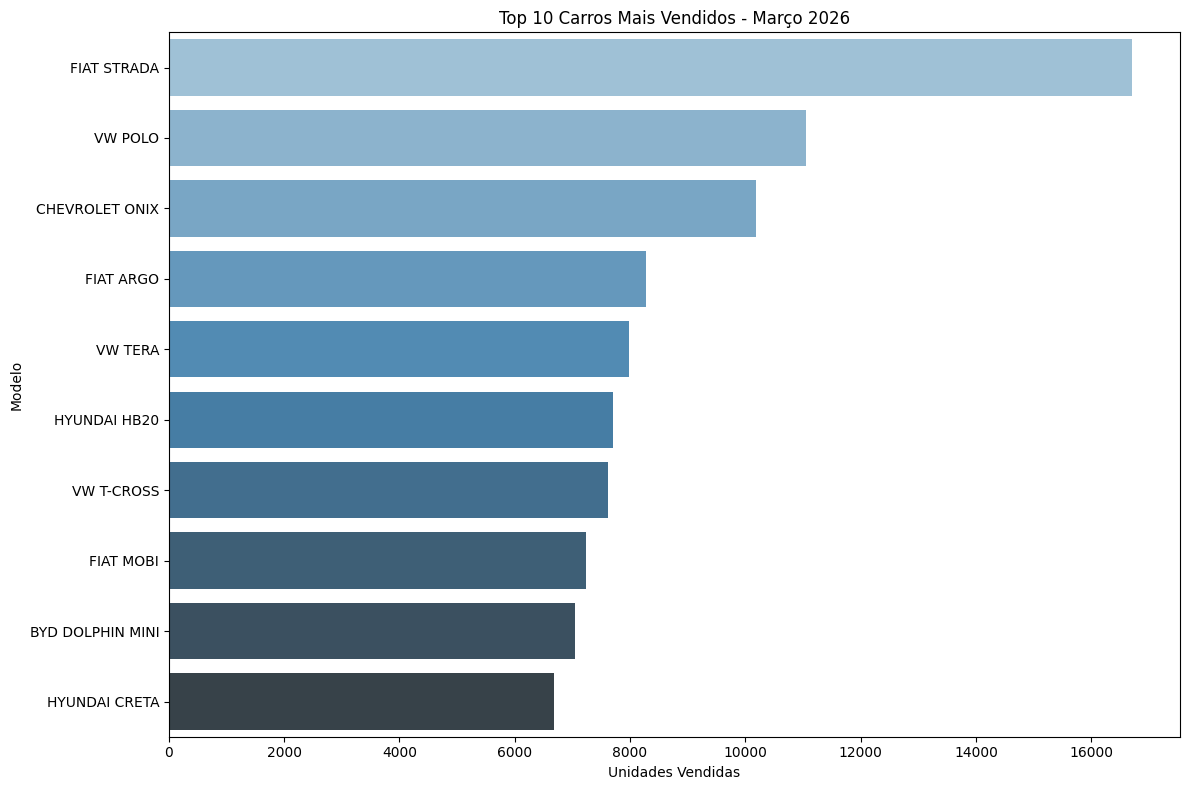

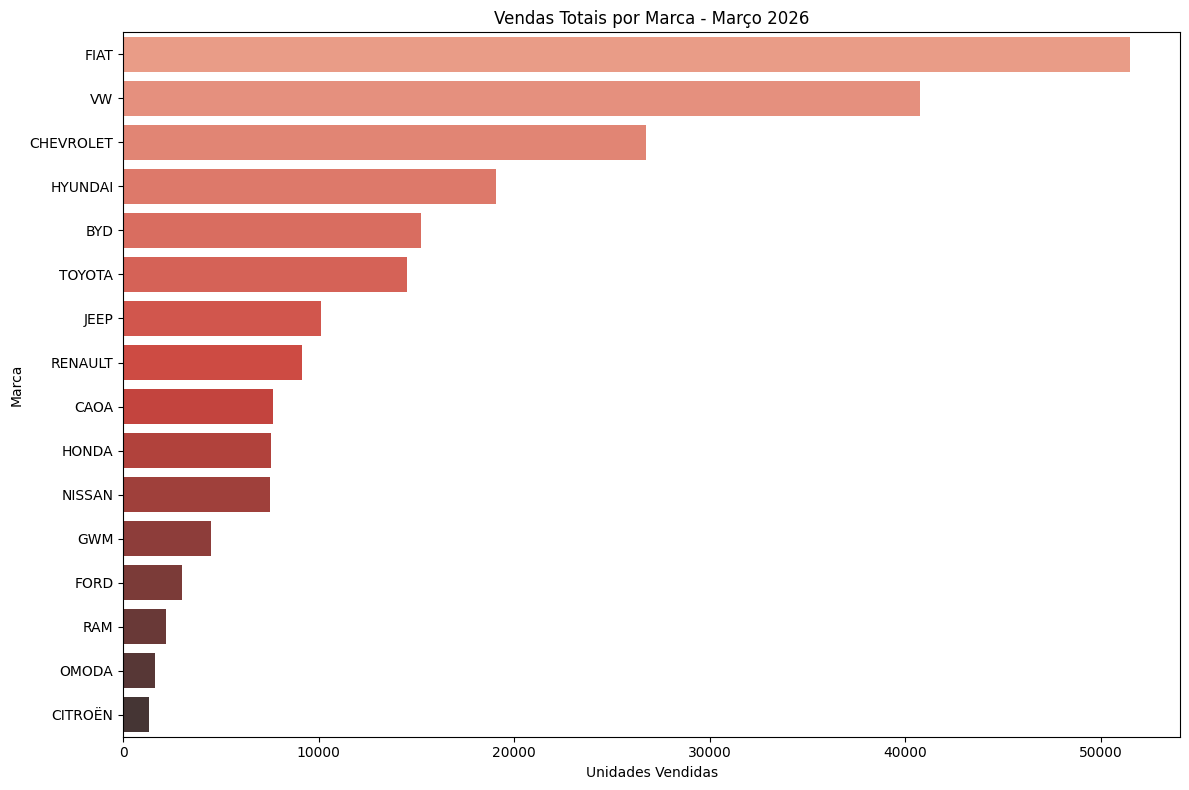

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#!pip install seaborn
import seaborn as sns

def realizar_analise_vendas():
    df = pd.read_csv('vendas_marco.csv') # Carrega o CSV que acabamos de criar
    
    col_vendas = df.columns[2] # Identifica a coluna de vendas (ex: 'MAR.2026')
    df[col_vendas] = pd.to_numeric(df[col_vendas], errors='coerce') # Garante que a coluna é numérica
    
    # 1. Gráfico de Barras: Top 10 Modelos mais Vendidos
    plt.figure(figsize=(12, 8))
    top_10 = df.head(10) # Pega os 10 primeiros, que já estão ordenados por vendas
    sns.barplot(data=top_10, x=col_vendas, y='MODELO', palette='Blues_d') # Cria o gráfico de barras
    plt.title('Top 10 Carros Mais Vendidos - Março 2026')
    plt.xlabel('Unidades Vendidas')
    plt.ylabel('Modelo')
    plt.tight_layout()
    plt.savefig('top_10_vendas.png') # Salva o gráfico como imagem
    
    # 2. Análise por Marca (Extraindo a primeira palavra do modelo)
    # Cria uma nova coluna 'MARCA' pegando a primeira palavra do nome do modelo (ex: 'FIAT STRADA' -> 'FIAT')
    df['MARCA'] = df['MODELO'].apply(lambda x: x.split()[0])
    # Agrupa as vendas por marca e soma as unidades vendidas, depois ordena
    vendas_por_marca = df.groupby('MARCA')[col_vendas].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=vendas_por_marca.values, y=vendas_por_marca.index, palette='Reds_d')
    plt.title('Vendas Totais por Marca - Março 2026')
    plt.xlabel('Unidades Vendidas')
    plt.ylabel('Marca')
    plt.tight_layout()
    plt.savefig('vendas_por_marca.png')
    
    # 3. Resumo Estatístico
    resumo = {
        'Total de Vendas (Top 50)': df[col_vendas].sum(),
        'Média de Vendas por Modelo': df[col_vendas].mean(),
        'Modelo mais Vendido': df.iloc[0]['MODELO'], # O primeiro modelo é o mais vendido
        'Marca com mais Vendas': vendas_por_marca.index[0] # A primeira marca é a com mais vendas
    }
    
    with open('resumo_vendas.txt', 'w') as f:
        f.write("RESUMO ESTATÍSTICO DE VENDAS - MARÇO 2026\n")
        f.write("="*40 + "\n")
        for k, v in resumo.items():
            f.write(f"{k}: {v}\n")
        f.write("\nTOP 5 MARCAS POR VOLUME:\n")
        f.write(vendas_por_marca.head(5).to_string())

if __name__ == "__main__":
    realizar_analise_vendas()
    print("Análise de vendas concluída!")

In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

url = "https://motor1.uol.com.br/features/783284/carros-mais-baratos-brasil-2026/"
def extrair_precos_baratos(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36)"
    }
    
    print(f"Acessando: {url}")
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    list_items = soup.find_all('li') # Encontra todas as tags <li>
    
    precos_data = []
    current_car = {} # Dicionário temporário para armazenar dados do carro atual
    
    for li in list_items:
        text = li.get_text(strip=True)
        
        if "Versão:" in text: # Se a linha contém "Versão:", é o início de um novo carro
            if current_car and 'preco' in current_car: # Se já temos um carro completo, adicionamos à lista
                precos_data.append(current_car)
            
            modelo_completo = text.replace("Versão:", "").strip()
            # Criamos uma chave para cruzar com os dados de vendas (ex: "RENAULT KWID")
            marca_modelo = " ".join(modelo_completo.split()[:2]).upper()
            current_car = {'modelo_completo': modelo_completo, 'modelo_chave': marca_modelo}
            
        elif "Preço:" in text and current_car: # Se a linha contém "Preço:" e estamos processando um carro
            preco_str = text.replace("Preço:", "").strip()
            # Usamos Expressões Regulares (re) para encontrar o número do preço
            match = re.search(r'R\\$\s*([\\d\\.]+)', preco_str)
            if match:
                valor = int(match.group(1).replace(".", "")) # Remove o ponto de milhar e converte para inteiro
                current_car['preco'] = valor
                
    if current_car and 'preco' in current_car: # Adiciona o último carro após o loop
        precos_data.append(current_car)
    
    return pd.DataFrame(precos_data)

if __name__ == "__main__":
    url = "https://motor1.uol.com.br/features/783284/carros-mais-baratos-brasil-2026/"
    df_precos = extrair_precos_baratos(url )
    
    if not df_precos.empty:
        df_precos.to_csv('precos_baratos.csv', index=False)
        print("Preços extraídos com sucesso!")
        print(df_precos)
    else:
        print("Nenhum preço encontrado.")

Acessando: https://motor1.uol.com.br/features/783284/carros-mais-baratos-brasil-2026/
Nenhum preço encontrado.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def realizar_analise_correlacao():
    # 1. Carregar os dados
    df_precos = pd.read_csv('precos_baratos.csv')
    df_vendas = pd.read_csv('vendas_marco.csv')
    
    # 2. Preparar os dados de vendas para o cruzamento
    # Cria a mesma 'modelo_chave' nos dados de vendas para que possamos cruzar os DataFrames
    df_vendas['modelo_chave'] = df_vendas['MODELO'].apply(lambda x: " ".join(x.split()[:2]).upper())
    # Correção para nomes que podem divergir (ex: 'VW' nos dados de vendas vs 'VOLKSWAGEN' nos preços)
    df_vendas['modelo_chave'] = df_vendas['modelo_chave'].str.replace('VW ', 'VOLKSWAGEN ')
    
    # 3. Cruzar os DataFrames (Merge)
    # Usamos pd.merge para combinar os dois DataFrames onde 'modelo_chave' é igual
    df_final = pd.merge(df_precos, df_vendas, on='modelo_chave', how='inner')
    
    if df_final.empty:
        print("Não foi possível cruzar os dados. Verifique as chaves de cruzamento.")
        return
    
    # 4. Análise de Correlação
    col_vendas = df_final.columns[4] # A coluna de vendas (MAR.2026) após o merge
    df_final[col_vendas] = pd.to_numeric(df_final[col_vendas], errors='coerce') # Garante que é numérico
    
    # Calcula o Coeficiente de Correlação de Pearson entre 'preco' e a coluna de vendas
    correlacao = df_final['preco'].corr(df_final[col_vendas])
    
    # 5. Visualização: Gráfico de Dispersão (Scatter Plot)
    plt.figure(figsize=(12, 8))
    # sns.regplot cria um gráfico de dispersão com uma linha de regressão linear
    sns.regplot(data=df_final, x='preco', y=col_vendas, scatter_kws={'s':100}, line_kws={"color": "red"})
    
    # Adiciona os nomes dos modelos ao lado de cada ponto para facilitar a identificação
    for i in range(df_final.shape[0]):
        plt.text(df_final.preco[i]+500, df_final[col_vendas][i], df_final.modelo_chave[i], 
                 fontsize=9, verticalalignment='center')
    
    plt.title(f'Correlação entre Preço e Vendas (Março 2026)\\nCoeficiente de Correlação: {correlacao:.2f}')
    plt.xlabel('Preço (R$)')
    plt.ylabel('Unidades Vendidas')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('grafico_correlacao.png')
    
    # 6. Salvar Resumo
    with open('resumo_correlacao.txt', 'w') as f:
        f.write("ANÁLISE DE CORRELAÇÃO: PREÇO vs VENDAS\\n")
        f.write("="*40 + "\\n")
        f.write(f"Coeficiente de Correlação de Pearson: {correlacao:.2f}\\n\\n")
        f.write("Interpretação:\\n")
        if correlacao < 0:
            f.write("- Existe uma correlação NEGATIVA: quanto MENOR o preço, MAIOR tende a ser o volume de vendas.\\n")
        else:
            f.write("- Existe uma correlação POSITIVA ou FRACA/NULA: o preço não parece ser o único fator determinante para o volume de vendas neste grupo, ou a relação é inversa.\\n")
        
        f.write("\\nDados Cruzados:\\n")
        f.write(df_final[['modelo_chave', 'preco', col_vendas]].to_string(index=False))

if __name__ == "__main__":
    realizar_analise_correlacao()
    print("Análise de correlação concluída!")

FileNotFoundError: [Errno 2] No such file or directory: 'precos_baratos.csv'